<a href="https://colab.research.google.com/github/Siddharth5723/Daily_learning/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-Nearest Neighbors (KNN) Implementation

## 1. Introduction to KNN

K-Nearest Neighbors (KNN) is a simple, non-parametric, supervised machine learning algorithm that can be used for both classification and regression tasks. It is widely used for its simplicity and effectiveness, especially in smaller datasets.

The algorithm works by finding the 'k' closest data points (neighbors) in the training dataset to a new, unseen data point. The class (for classification) or the value (for regression) of the new data point is then determined by the majority class or the average value of these 'k' neighbors.

## 2. Data Generation and Visualization

Let's start by generating some synthetic data for a binary classification problem. We'll use `make_classification` from `sklearn.datasets`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Generate synthetic data
X, y = make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1,
    random_state=42, class_sep=1.5
)

df = pd.DataFrame(X, columns=['feature_1', 'feature_2'])
df['target'] = y

display(df.head())

,feature_1,feature_2,target
0,-0.372929,0.513042,1
1,1.812935,3.270534,1
2,2.840428,2.920996,1
3,2.794548,0.095620,1
4,1.444105,0.977241,1


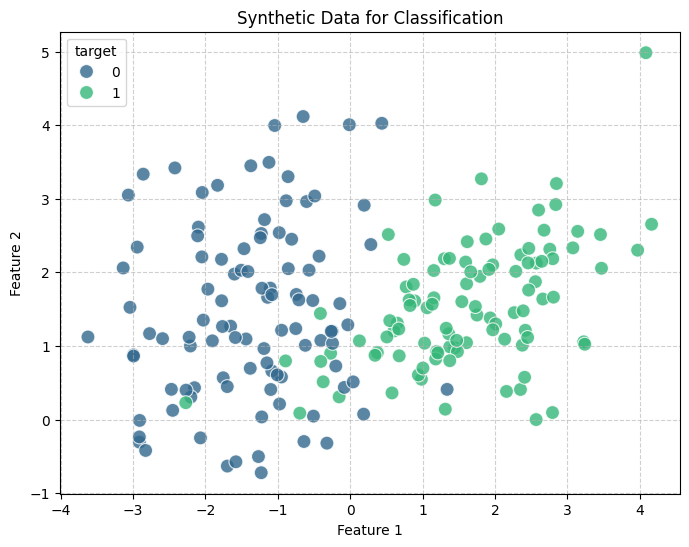

In [2]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='feature_1', y='feature_2', hue='target', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('Synthetic Data for Classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## 3. Data Preprocessing: Splitting and Scaling

Before applying KNN, it's crucial to split the data into training and testing sets and scale the features. KNN is a distance-based algorithm, so feature scaling is very important to ensure that all features contribute equally to the distance calculation.

In [3]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures scaled successfully.")

X_train shape: (140, 2)
X_test shape: (60, 2)
y_train shape: (140,)
y_test shape: (60,)

Features scaled successfully.


## 4. KNN Model Training and Prediction

Now we will train the KNN classifier on the scaled training data. We need to choose a value for `k`, the number of neighbors. Let's start with `k=5`.

In [4]:
# Initialize and train the KNN classifier
k = 5 # Number of neighbors
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = knn.predict(X_test_scaled)

print(f"Predictions made for k={k}.")

Predictions made for k=5.


## 5. Model Evaluation

Let's evaluate the performance of our KNN model using common classification metrics like accuracy, confusion matrix, and a classification report.

Accuracy Score: 0.9500

Confusion Matrix:
[[30  0]
 [ 3 27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        30
           1       1.00      0.90      0.95        30

    accuracy                           0.95        60
   macro avg       0.95      0.95      0.95        60
weighted avg       0.95      0.95      0.95        60



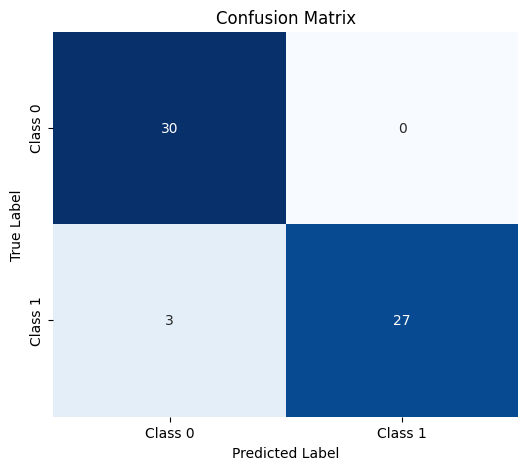

In [5]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy Score: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## 6. Finding Optimal `k` Value (Optional but Recommended)

The choice of `k` is critical for KNN performance. We can iterate through different `k` values and plot the accuracy to find the optimal `k`.

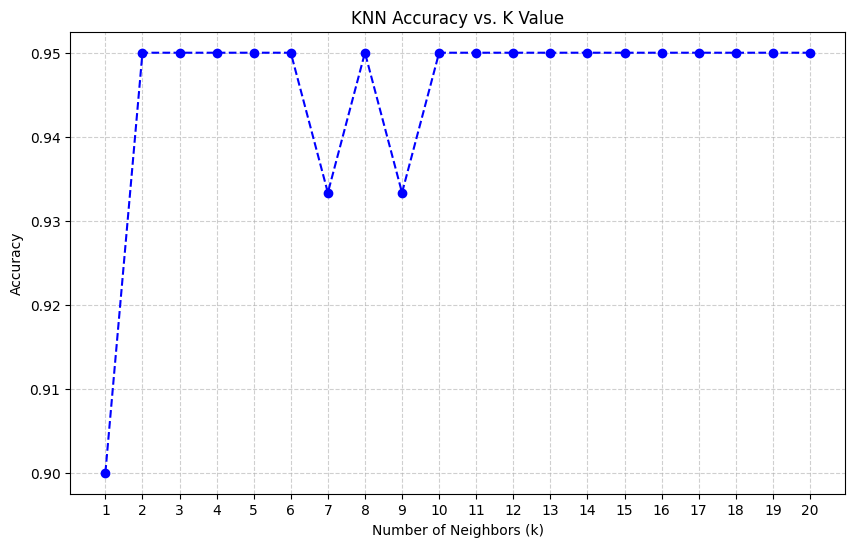

Optimal k value: 2 with accuracy: 0.9500


In [6]:
k_values = list(range(1, 21)) # Test k from 1 to 20
accuracies = []

for k_val in k_values:
    knn_opt = KNeighborsClassifier(n_neighbors=k_val)
    knn_opt.fit(X_train_scaled, y_train)
    y_pred_opt = knn_opt.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred_opt))

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='--', color='blue')
plt.title('KNN Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

optimal_k = k_values[np.argmax(accuracies)]
max_accuracy = np.max(accuracies)
print(f"Optimal k value: {optimal_k} with accuracy: {max_accuracy:.4f}")

## 7. Conclusion

This notebook demonstrates a complete workflow for implementing the K-Nearest Neighbors algorithm for classification:

1.  **Data Generation/Loading:** Creating or importing a dataset.
2.  **Data Visualization:** Understanding the data distribution.
3.  **Preprocessing:** Splitting data into training/testing sets and scaling features.
4.  **Model Training:** Initializing and training the `KNeighborsClassifier`.
5.  **Model Evaluation:** Assessing performance using accuracy, confusion matrix, and classification report.
6.  **Hyperparameter Tuning (Optional):** Finding an optimal `k` value for the model.

KNN is a powerful yet simple algorithm, and understanding these steps is crucial for effective machine learning.